In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
%matplotlib inline 

## Hyperparameter Tuning

##### Hyperparameters: Parameters that are not learned from the data but are set before training the model

##### Comparison between Grid Search and Randomized Search
![Comparison between Grid Search and Randomized Search](grid_search.png) 
##### Image Source: https://360digitmg.com/blog/comparison-gridsearchcv-and-randomsearchcv
##### Image Link: https://images.app.goo.gl/wgBAw3qXwiuJ7TWz5

## Example

In [3]:
filename = 'bank_edited.csv'
orig_df = pd.read_csv(filename)
orig_df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


In [4]:
orig_df.shape

(4521, 17)

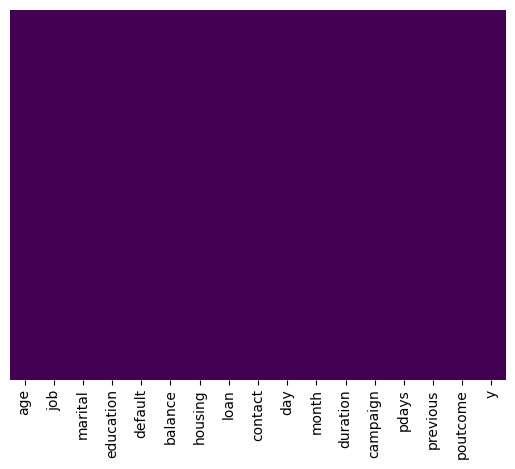

In [5]:
sns.heatmap(orig_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

In [6]:
null_percent = orig_df.isnull().sum()/len(orig_df)*100
null_percent

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
y            0.0
dtype: float64

In [7]:
orig_df['y'] = orig_df['y'].map({'yes': 1, 'no': 0})
orig_df['y'].value_counts()

y
0    4000
1     521
Name: count, dtype: int64

In [8]:
cleaned_df = orig_df.copy()

In [9]:
cleaned_df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object

In [10]:
cleaned_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [11]:
cleaned_df.describe()

,age,balance,day,duration,campaign,pdays,previous,y
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579,0.115240
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562,0.319347
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000,1.000000


### Set Up Data

In [12]:
df = cleaned_df.copy()

In [13]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [14]:
# Create list of input attributes and output variable
output_var = 'y'
input_vars = ['age', 'balance', 'day', 'duration', 'campaign']
# Create attribute input and output datasets
X = df[input_vars]
y = df[output_var]

### Data Preparation

In [15]:
# Split training : testing datasets as 80:20 ratio
# Note that 0.20 can be changed to other ratios.
test_percent = 0.2
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_percent, random_state = 0)

In [16]:
# Standardization
from sklearn.preprocessing import StandardScaler
num_X_train = X_train.select_dtypes(include=np.number)
scaled_X_train = StandardScaler().fit_transform(num_X_train)
num_X_test = X_test.select_dtypes(include=np.number)
scaled_X_test = StandardScaler().fit_transform(num_X_test)
scaled_X_train

array([[-1.42456581, -0.26704978,  1.46909422, -0.58769379, -0.58684814],
       [-0.95486307, -0.462516  ,  1.46909422, -0.59566376,  0.71362244],
       [ 1.01788844, -0.46022025,  1.46909422, -0.3485947 , -0.58684814],
       ...,
       [ 1.11182899, -0.3664227 ,  1.46909422,  0.51216202,  0.06338715],
       [-0.86092252, -0.25622698, -0.95537052,  1.05411995, -0.58684814],
       [ 0.36030461, -0.57238376, -0.83414729, -0.13739051, -0.26173049]],
      shape=(3616, 5))

## Random Forest

### Parameter Set Search

In [17]:
parameters = [{'n_estimators': [100, 500, 1000], 
               'max_depth': [10, 20, 50]}]

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier()  

In [28]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(rf_classifier,
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 5,
                           n_jobs = 16)
grid_search.fit(X_train, y_train)
print("Best Accuracy: {:.2f}".format(grid_search.best_score_))
print("Best Parameters:", grid_search.best_params_)
# Best Accuracy: ??
# Best Parameters: {'max_depth': ??, 'n_estimators': ??}

Best Accuracy: 0.89
Best Parameters: {'max_depth': 50, 'n_estimators': 1000}


In [29]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
grid_search = HalvingGridSearchCV(rf_classifier,
                                  parameters,
                                  scoring = 'accuracy',
                                  cv=5,
                                  n_jobs=16)
grid_search.fit(X_train, y_train)
print("Best Accuracy: {:.2f}".format(grid_search.best_score_))
print("Best Parameters:", grid_search.best_params_)
# Best Accuracy: ??
# Best Parameters: {'max_depth': ??, 'n_estimators': ??}

Best Accuracy: 0.88
Best Parameters: {'max_depth': 20, 'n_estimators': 1000}


In [30]:
from sklearn.model_selection import RandomizedSearchCV
grid_search = RandomizedSearchCV(rf_classifier,
                                 param_distributions = parameters,
                                 scoring = 'accuracy',
                                 cv=5,
                                 n_jobs=16)
grid_search.fit(X_train, y_train)
print("Best Accuracy: {:.2f}".format(grid_search.best_score_))
print("Best Parameters:", grid_search.best_params_)
# Best Accuracy: ??
# Best Parameters: {'max_depth': ??, 'n_estimators': ??}

/nix/store/7z2dg71ml14s84dm1jf4barbvcdzxq61-devenv-profile/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Accuracy: 0.89
Best Parameters: {'n_estimators': 500, 'max_depth': 50}


### Performance Evaluation:

In [31]:
# From GridSearchCV
# Best Accuracy: ??
# Best Parameters: {'max_depth': ??, 'n_estimators': ??}

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_classifier = RandomForestClassifier(n_estimators=1000, max_depth=50)  
rf_classifier.fit(X_train, y_train)
y_predicted = rf_classifier.predict(X_test)
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       793
           1       0.53      0.27      0.36       112

    accuracy                           0.88       905
   macro avg       0.71      0.62      0.64       905
weighted avg       0.86      0.88      0.86       905



In [32]:
# From HalvingGridSearchCV
# Best Accuracy: ??
# Best Parameters: {'max_depth': ??, 'n_estimators': ??}

rf_classifier = RandomForestClassifier(n_estimators=1000, max_depth=20)  
rf_classifier.fit(X_train, y_train)
y_predicted = rf_classifier.predict(X_test)
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       793
           1       0.53      0.28      0.36       112

    accuracy                           0.88       905
   macro avg       0.72      0.62      0.65       905
weighted avg       0.86      0.88      0.86       905



In [33]:
# From Randomized Search
# Best Accuracy: ??
# Best Parameters: {'max_depth': ??, 'n_estimators': ??}

rf_classifier = RandomForestClassifier(n_estimators=500, max_depth=50)  
rf_classifier.fit(X_train, y_train)
y_predicted = rf_classifier.predict(X_test)
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       793
           1       0.52      0.26      0.35       112

    accuracy                           0.88       905
   macro avg       0.71      0.61      0.64       905
weighted avg       0.85      0.88      0.86       905



## Neural Network: Classification

### Parameter Set Search: 

In [34]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier()

In [35]:
parameters = [{'hidden_layer_sizes': [(15,15,15), (15,10,5), (15, 15), (15,10), (10,10), (5,5), (15), (10), (5)], 
               'activation': ['identity', 'tanh', 'relu'],
               'max_iter': [5000]}]

In [36]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator = model,
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 5,
                           n_jobs = -1)
grid_search.fit(scaled_X_train, y_train)
print("Best Accuracy: {:.2f}".format(grid_search.best_score_))
print("Best Parameters:", grid_search.best_params_)
# Best Accuracy: ??
# Best Parameters: {'activation': ??, 'hidden_layer_sizes': ??, 'max_iter': ??}

Best Accuracy: 0.89
Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (5, 5), 'max_iter': 5000}


In [37]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
grid_search = HalvingGridSearchCV(model,
                                  param_grid = parameters,
                                  cv=5,
                                  n_jobs=-1)
grid_search.fit(scaled_X_train, y_train)
print("Best Accuracy: {:.2f}".format(grid_search.best_score_))
print("Best Parameters:", grid_search.best_params_)
# Best Accuracy: ??
# Best Parameters: {'activation': ??, 'hidden_layer_sizes': ??, 'max_iter': ??}

Best Accuracy: 0.89
Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': 10, 'max_iter': 5000}


In [38]:
from sklearn.model_selection import RandomizedSearchCV
grid_search = RandomizedSearchCV(model,
                                 param_distributions = parameters,
                                 cv=5,
                                 n_jobs=-1)
grid_search.fit(scaled_X_train, y_train)
print("Best Accuracy: {:.2f}".format(grid_search.best_score_))
print("Best Parameters:", grid_search.best_params_)
# Best Accuracy: ??
# Best Parameters: {'activation': ??, 'hidden_layer_sizes': ??, 'max_iter': ??}

Best Accuracy: 0.89
Best Parameters: {'max_iter': 5000, 'hidden_layer_sizes': (15, 10), 'activation': 'relu'}


### Performance Evaluation:

In [39]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

In [40]:
# From GridSearchCV
# Best Accuracy: ??
# Best Parameters: {'activation': ??, 'hidden_layer_sizes': ??, 'max_iter': ??}

model = MLPClassifier(hidden_layer_sizes=(15, 10), activation='relu', max_iter=5000)
model.fit(scaled_X_train, y_train)
y_predicted = model.predict(scaled_X_test)
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       793
           1       0.55      0.15      0.24       112

    accuracy                           0.88       905
   macro avg       0.72      0.57      0.59       905
weighted avg       0.85      0.88      0.85       905



In [41]:
# From HalvingGridSearchCV
# Best Accuracy: ??
# Best Parameters: {'activation': ??, 'hidden_layer_sizes': ??, 'max_iter': ??}

model = MLPClassifier(hidden_layer_sizes=(15), activation='relu', max_iter=5000)
model.fit(scaled_X_train, y_train)
y_predicted = model.predict(scaled_X_test)
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.89      0.98      0.94       793
           1       0.57      0.15      0.24       112

    accuracy                           0.88       905
   macro avg       0.73      0.57      0.59       905
weighted avg       0.85      0.88      0.85       905



In [42]:
# From RandomizedSearchCV
# Best Accuracy: ??
# Best Parameters: {'activation': ??, 'hidden_layer_sizes': ??, 'max_iter': ??}

model = MLPClassifier(hidden_layer_sizes=(10), activation='relu', max_iter=5000)
model.fit(scaled_X_train, y_train)
y_predicted = model.predict(scaled_X_test)
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       793
           1       0.62      0.14      0.23       112

    accuracy                           0.88       905
   macro avg       0.75      0.57      0.58       905
weighted avg       0.86      0.88      0.85       905

